# Wrapper-Based Feature Selection

## Objective
To apply model-dependent feature selection techniques
and evaluate their impact on classification performance.

Methods:
- Sequential Forward Selection (SFS)
- Sequential Backward Selection (SBS)
- Sequential Floating Forward Selection (SFFS)
- Sequential Floating Backward Selection (SFBS)

In [2]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_score, f1_score, roc_auc_score

from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier

from mlxtend.feature_selection import SequentialFeatureSelector as SFS

In [3]:
df = pd.read_csv(r"C:\ML PROJECT\Dimensionality-Reduction-Classification-Study\data\raw_data\breast_cancer.csv")

X = df.drop("target", axis=1)
y = df["target"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

### Choose Base Model for Feature Selection

In [4]:
base_model = RandomForestClassifier(random_state=42)

### Sequential Forward Selection (SFS)

In [5]:
sfs_forward = SFS(
    base_model,
    k_features=8,
    forward=True,
    floating=False,
    scoring='accuracy',
    cv=5,
    n_jobs=-1
)

sfs_forward.fit(X_train_scaled, y_train)

selected_features_forward = list(sfs_forward.k_feature_idx_)

In [6]:
X_train_sfs = X_train_scaled[:, selected_features_forward]
X_test_sfs = X_test_scaled[:, selected_features_forward]

### Sequential Backward Selection (SBS)

In [7]:
sfs_backward = SFS(
    base_model,
    k_features=8,
    forward=False,
    floating=False,
    scoring='accuracy',
    cv=5,
    n_jobs=-1
)

sfs_backward.fit(X_train_scaled, y_train)

selected_features_backward = list(sfs_backward.k_feature_idx_)

X_train_sbs = X_train_scaled[:, selected_features_backward]
X_test_sbs = X_test_scaled[:, selected_features_backward]

### Sequential Floating Forward Selection (SFFS)

In [8]:
sfs_floating_forward = SFS(
    base_model,
    k_features=8,
    forward=True,
    floating=True,
    scoring='accuracy',
    cv=5,
    n_jobs=-1
)

sfs_floating_forward.fit(X_train_scaled, y_train)

selected_features_sffs = list(sfs_floating_forward.k_feature_idx_)

X_train_sffs = X_train_scaled[:, selected_features_sffs]
X_test_sffs = X_test_scaled[:, selected_features_sffs]

### Sequential Floating Backward Selection (SFBS)

In [10]:
sfs_floating_backward = SFS(
    base_model,
    k_features=8,
    forward=False,
    floating=True,
    scoring='accuracy',
    cv=5,
    n_jobs=-1
)

sfs_floating_backward.fit(X_train_scaled, y_train)

selected_features_sfbs = list(sfs_floating_backward.k_feature_idx_)

X_train_sfbs = X_train_scaled[:, selected_features_sfbs]
X_test_sfbs = X_test_scaled[:, selected_features_sfbs]

In [11]:
def evaluate_models(X_train, X_test, y_train, y_test, method_name):
    models = {
        "Random Forest": RandomForestClassifier(random_state=42),
        "Decision Tree": DecisionTreeClassifier(random_state=42),
        "SVM": SVC(probability=True, random_state=42),
        "Naive Bayes": GaussianNB(),
        "KNN": KNeighborsClassifier()
    }

    results = []

    for name, model in models.items():
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
        y_prob = model.predict_proba(X_test)[:, 1]

        results.append({
            "Method": method_name,
            "Model": name,
            "Accuracy": accuracy_score(y_test, y_pred),
            "Precision": precision_score(y_test, y_pred),
            "F1 Score": f1_score(y_test, y_pred),
            "ROC-AUC": roc_auc_score(y_test, y_prob)
        })

    return pd.DataFrame(results)

In [12]:
results_sfs = evaluate_models(X_train_sfs, X_test_sfs, y_train, y_test, "SFS")
results_sbs = evaluate_models(X_train_sbs, X_test_sbs, y_train, y_test, "SBS")
results_sffs = evaluate_models(X_train_sffs, X_test_sffs, y_train, y_test, "SFFS")
results_sfbs = evaluate_models(X_train_sfbs, X_test_sfbs, y_train, y_test, "SFBS")

wrapper_results = pd.concat([
    results_sfs,
    results_sbs,
    results_sffs,
    results_sfbs
])

wrapper_results

,Method,Model,Accuracy,Precision,F1 Score,ROC-AUC
0,SFS,Random Forest,0.947368,0.958333,0.958333,0.988922
1,SFS,Decision Tree,0.903509,0.955224,0.920863,0.908730
2,SFS,SVM,0.947368,0.971429,0.957746,0.993056
3,SFS,Naive Bayes,0.921053,0.956522,0.936170,0.978505
4,SFS,KNN,0.929825,0.944444,0.944444,0.977017
0,SBS,Random Forest,0.964912,0.972222,0.972222,0.994874
1,SBS,Decision Tree,0.912281,0.969697,0.927536,0.920635
2,SBS,SVM,0.938596,0.971014,0.950355,0.995040
3,SBS,Naive Bayes,0.929825,0.957143,0.943662,0.988757
4,SBS,KNN,0.921053,0.956522,0.936170,0.988095


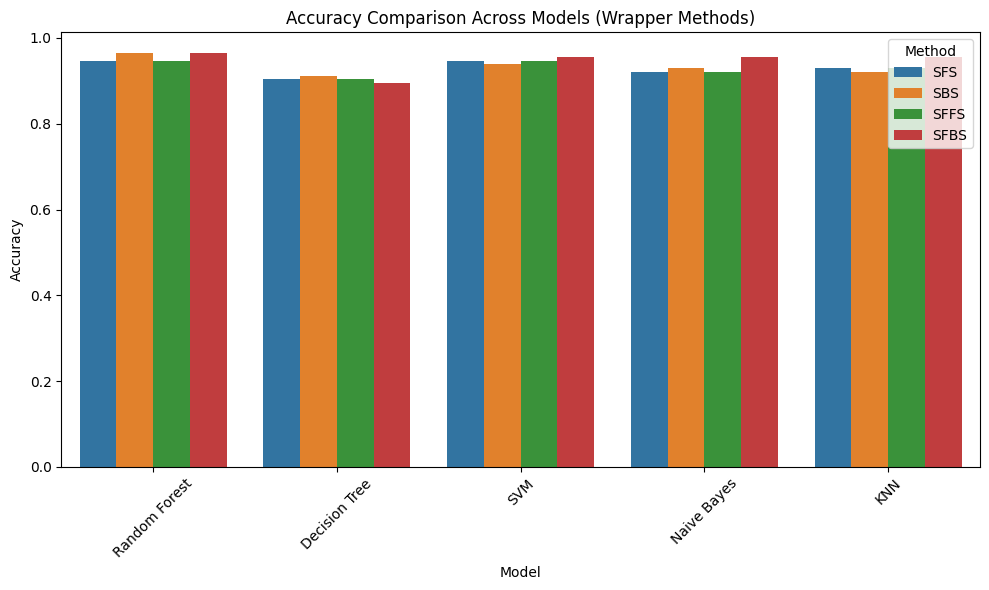

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,6))
sns.barplot(data=wrapper_results, x="Model", y="Accuracy", hue="Method")
plt.title("Accuracy Comparison Across Models (Wrapper Methods)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [15]:
wrapper_results.to_csv(r"C:\ML PROJECT\Dimensionality-Reduction-Classification-Study\results\wrapper_results.csv", index=False)